Lap time anlysis and comparison: Perez vs Verstapen- Abu Dhabi GP 2021

Objective was to compare lap time pace between two racers on the same team, this case being Red Bull. This helped use conclude if raw lap time data is a good representation of actual driving pace.
The method used was loading lap by lap timing using Pandas and then filtering down to the two drivers for the specific race. This was then followed up by converting miliseconds to seconds to then calculate summary statistics like mean,standard deviation,minimum and maximum.

In [2]:
import pandas as pd
laps = pd.read_csv('lap_times.csv') 
races = pd.read_csv('races.csv')
drivers = pd.read_csv('drivers.csv')
circuits = pd.read_csv('circuits.csv')

laps.head()

,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [4]:
drivers[['driverId', 'forename', 'surname']].head(20)

,driverId,forename,surname
0,1,Lewis,Hamilton
1,2,Nick,Heidfeld
2,3,Nico,Rosberg
3,4,Fernando,Alonso
4,5,Heikki,Kovalainen
5,6,Kazuki,Nakajima
6,7,Sébastien,Bourdais
7,8,Kimi,Räikkönen
8,9,Robert,Kubica
9,10,Timo,Glock


In [11]:
circuits[['circuitId', 'name', 'location']].head(30)

,circuitId,name,location
0,1,Albert Park Grand Prix Circuit,Melbourne
1,2,Sepang International Circuit,Kuala Lumpur
2,3,Bahrain International Circuit,Sakhir
3,4,Circuit de Barcelona-Catalunya,Montmeló
4,5,Istanbul Park,Istanbul
5,6,Circuit de Monaco,Monte-Carlo
6,7,Circuit Gilles Villeneuve,Montreal
7,8,Circuit de Nevers Magny-Cours,Magny Cours
8,9,Silverstone Circuit,Silverstone
9,10,Hockenheimring,Hockenheim


In [12]:
 races[(races['year'] == 2021) & (races['name'].str.contains('Abu Dhabi'))][['raceId', 'name', 'date']]

,raceId,name,date
1057,1073,Abu Dhabi Grand Prix,2021-12-12


In [16]:

drivers[(drivers['surname'] == 'Verstappen') & (drivers['forename'] == 'Max')][['driverId', 'forename', 'surname']]


,driverId,forename,surname
829,830,Max,Verstappen


In [15]:
drivers[drivers['surname'].isin(['Pérez'])][['driverId', 'forename', 'surname']]

,driverId,forename,surname
814,815,Sergio,Pérez


In [23]:
race_id = 1073
driver_ids = [830, 815]

comparison = laps[(laps['raceId'] == race_id) & (laps['driverId'].isin(driver_ids))]
comparison.head()
comparison = comparison.copy() # avoids a Pandas warning
comparison['lap_time_sec'] = comparison['milliseconds'] / 1000
comparison.head()


,raceId,driverId,lap,position,time,milliseconds,lap_time_sec
513652,1073,830,1,2,1:32.800,92800,92.800
513653,1073,830,2,2,1:29.103,89103,89.103
513654,1073,830,3,2,1:28.827,88827,88.827
513655,1073,830,4,2,1:29.026,89026,89.026
513656,1073,830,5,2,1:28.718,88718,88.718


In [24]:
comparison.groupby('driverId')['lap_time_sec'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
driverId,,,,
815,91.864927,10.304537,86.419,136.838
830,93.402500,15.280340,86.103,150.435


Initial findings-


Raw averages show Perez (91.86s) as faster than Verstappen (93.40). Some key to note is that both drivers max lap times are far above their mean (136 seconds, 150 seconds)

In [27]:
comparison.groupby('driverId')['lap'].count()

driverId
815    55
830    58
Name: lap, dtype: int64

Check of data quality-


Laps 56-58 of Perez’s data is missing. It is confirmed that it is the actual data itself and not an error with the filtering. No estimations were done as this will affect the purity of the analysis.


In [26]:
comparison[comparison['lap_time_sec'] > 110]
comparison.shape

(113, 7)

In [28]:
perez_laps = comparison[comparison['driverId'] == 815]['lap'].sort_values()
all_laps = set(range(1, 59))
missing = all_laps - set(perez_laps)
print(missing)

{56, 57, 58}


In [29]:
laps[(laps['raceId'] == 1073) & (laps['driverId'] == 815)]['lap'].max()

np.int64(55)

Note: Pérez's data is missing laps 56-58. This is likely linked to the
race's controversial safety-car-affected finish. Left as-is rather than
estimated, since inventing values would distort the analysis.

In [40]:
mean = comparison['lap_time_sec'].mean()
std = comparison['lap_time_sec'].std()
threshold = mean + 2*std

comparison['likely_sc'] = comparison['lap_time_sec'] > threshold
print(threshold)


118.77848846999132


Investigating outliers-


Flagged down all outlier laps by calculating the mean plus two standard deviations giving an outlier threshold of 118.78s this allows for a reproducible method that can be repeated to form a consistency during future investigations.
Notably, this method also correctly keeps pit stop laps (roughly up to 115s) kept as regular racing laps leading to the specific  isolation of safety car periods (laps 36-37 and 53-58) 



In [41]:
comparison = comparison.copy()
mean = comparison['lap_time_sec'].mean()
std = comparison['lap_time_sec'].std()
threshold = mean + 2*std

comparison['likely_sc'] = comparison['lap_time_sec'] > threshold

comparison[comparison['likely_sc'] == False].groupby('driverId')['lap_time_sec'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
driverId,,,,
815,89.791000,5.396899,86.419,112.799
830,88.954811,4.027126,86.103,107.251


Corrected Findings- 

When safety car laps were excluded Verstappen was faster on average and more consistent than Perez, this is the opposite to the conclusion that would be drawn from the raw data.
Perez having a slightly higher std show that this is probably his two retained pit stop laps, these create a natural variation without being outliers 


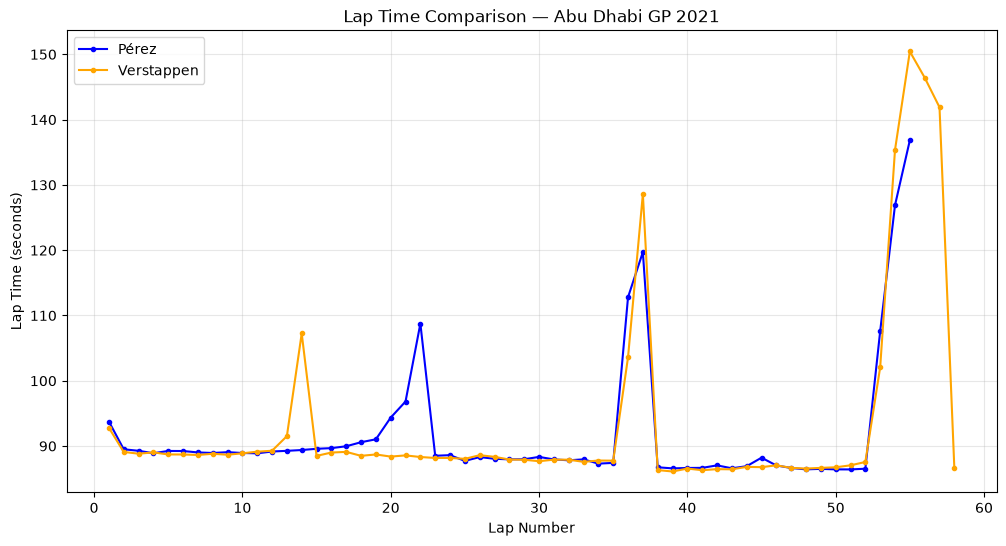

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for driver_id, label, color in [(815, 'Pérez', 'blue'), (830, 'Verstappen', 'orange')]:
    driver_data = comparison[comparison['driverId'] == driver_id].sort_values('lap')
    plt.plot(driver_data['lap'], driver_data['lap_time_sec'], label=label, color=color, marker='o', markersize=3)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Lap Time Comparison — Abu Dhabi GP 2021')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Line chart patterns-

Plotting that lap times across the whole race revealed two more, much smaller, spikes in the charts around laps 13-14 and 21-22 that were left out correctly by the statistical threshold of 118.78s
Cross-referencing against the official race reports, confirming that all four spikes were genuine race events:

- Lap 13–14: Verstappen's and Pérez's respective early pit stops
- Lap 21–22: Pérez's pit stop after defending against Hamilton
- Lap 36–37: Virtual Safety Car + Pérez's second pit stop
- Lap 53–58: Full Safety Car after Nicholas Latifi's crash, during which
both Red Bull drivers pitted for soft tyres


<Figure size 800x600 with 0 Axes>

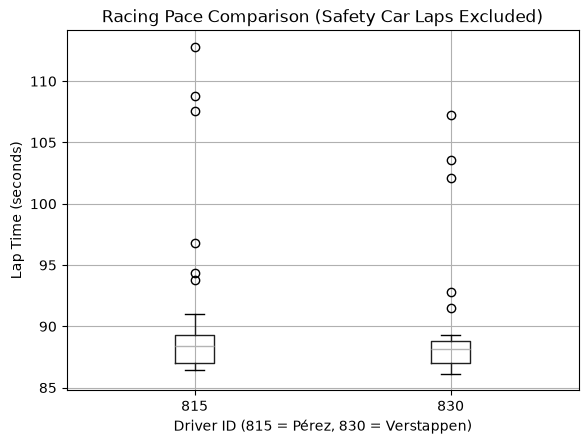

In [43]:
clean_data = comparison[comparison['likely_sc'] == False]

plt.figure(figsize=(8, 6))
clean_data.boxplot(column='lap_time_sec', by='driverId')
plt.xlabel('Driver ID (815 = Pérez, 830 = Verstappen)')
plt.ylabel('Lap Time (seconds)')
plt.title('Racing Pace Comparison (Safety Car Laps Excluded)')
plt.suptitle('')
plt.show()

Verstappen's pace sits slightly lower and tighter then Perez once safety car laps are excluded

Conclusion-

This analysis presents the importance of correctly classifying
Non representative data points before drawing performance conclusions. Raw
lap time averages were affected by external race events (pit stops, safety
cars) rather than reflecting true driver pace which in turn reversed which driver
appeared faster.

A statistical outlier threshold (mean + two standard deviations) proved to be very
Precise as it correctly distinguishing brief pit
stops from genuine safety car periods.

Pérez's final three laps are missing from the source
dataset, likely linked to the race's safety-car-affected finish, and were
left unestimated. The outlier method still relies on lap time alone;
incorporating official pit stop timing data would allow pit stops and
safety car periods to be distinguished with certainty rather than inferred